# Phần 4: Tiền xử lý dữ liệu chuỗi thời gian
## Bước 3: Kỹ nghệ Đặc trưng, Phát hiện Dị thường & Đánh giá Pipeline

Notebook này tiếp nhận dữ liệu đã được làm sạch và phân rã từ Bước 2 (thư mục `data/processed`) để thực hiện trích xuất đặc trưng, phát hiện dị thường và xây dựng mô hình dự báo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import networkx as nx
import warnings

from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import grangercausalitytests

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
# 1. Load dữ liệu đã qua tiền xử lý từ Notebook 2
df_proc = pd.read_csv('../data/processed/P4_energy_dataset_processed.csv', parse_dates=['time']).set_index('time')

# Ánh xạ các biến để sử dụng cho các bước tiếp theo
ts_clean = df_proc['load_clean']
ts_deseasonalized = df_proc['deseasonalized']
ts_detrend = df_proc['detrend']
ts_diff = df_proc['ts_diff'].bfill() # dòng đầu không có sai phân
ts_resid = df_proc['stl_resid']
stl_trend = df_proc['stl_trend']
stl_seasonal = df_proc['stl_seasonal']

display(df_proc.head())

,load_clean,stl_trend,stl_seasonal,stl_resid,detrend,deseasonalized,ts_diff
time,,,,,,,
2014-12-31 23:00:00+00:00,25385.0,23243.673483,-7586.413000,9727.739517,2141.326517,32971.413000,NaN
2015-01-01 00:00:00+00:00,24382.0,23270.724956,663.759236,447.515808,1111.275044,23718.240764,-24.759924
2015-01-01 01:00:00+00:00,22734.0,23297.773271,-297.698056,-266.075215,-563.773271,23031.698056,-41.507717
2015-01-01 02:00:00+00:00,21286.0,23324.818377,-2620.750716,581.932339,-2038.818377,23906.750716,-37.387793
2015-01-01 03:00:00+00:00,20264.0,23351.860220,-2728.054146,-359.806075,-3087.860220,22992.054146,-26.950461


### a) Phát hiện dị thường trên chuỗi thời gian (Z-score, Isolation Forest, STL Residual Thresholding)

Phát hiện dị thường nhằm nhận diện các điểm quan sát lệch đáng kể khỏi hành vi vận hành bình thường của hệ thống điện. trong noteboook này, dùng kết hợp phương pháp thống kê (Z-score), học máy không giám sát (Isolation Forest) và ngưỡng trên phần dư STL để tăng độ tin cậy.

**Công thức toán học:**
- **Z-score Anomaly Detection**
$$
z_t = \frac{x_t - \mu}{\sigma}, \quad \text{anomaly nếu } |z_t| > 3
$$
trong đó $x_t$ là giá trị tại thời điểm $t$, $\mu$ là trung bình, $\sigma$ là độ lệch chuẩn.

- **Isolation Forest (khái niệm độ dài đường đi)**
$$
s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}
$$
với $h(x)$ là độ dài đường đi để cô lập điểm $x$ trong cây ngẫu nhiên, $E[h(x)]$ là kỳ vọng theo rừng cây, $c(n)$ là hệ số chuẩn hóa theo kích thước mẫu $n$. Điểm có đường đi ngắn (dễ bị cô lập) sẽ có xu hướng là dị thường.

- **STL Residual Thresholding**
$$
\text{anomaly nếu } |r_t| > k\,\sigma_r \quad (k=3)
$$
trong đó $r_t$ là residual từ STL và $\sigma_r$ là độ lệch chuẩn của residual.

In [3]:
anomalies = pd.DataFrame(index=ts_clean.index)

# 1. Phương pháp Thống kê: Z-score trên chuỗi đã deseasonalize
z_scores = (ts_deseasonalized - ts_deseasonalized.mean()) / ts_deseasonalized.std()
anomalies['Z_Score_Anomaly'] = (np.abs(z_scores) > 3).astype(int)

# 2. Isolation Forest trên cửa sổ trượt (Rolling Window)
roll_features = pd.DataFrame({
    'mean_24h': ts_clean.rolling(24).mean(),
    'std_24h': ts_clean.rolling(24).std()
}).dropna()

iso_forest = IsolationForest(contamination=0.01, random_state=42)
iso_preds = iso_forest.fit_predict(roll_features)
anomalies['IsoForest_Anomaly'] = 0
anomalies.loc[roll_features.index, 'IsoForest_Anomaly'] = (iso_preds == -1).astype(int)

# 3. Dựa trên tái tạo (STL Residual Thresholding)
resid_std = ts_resid.std()
anomalies['STL_Resid_Anomaly'] = (np.abs(ts_resid) > 3 * resid_std).astype(int)

print("Số lượng điểm dị thường phát hiện được:")
print(anomalies.sum())

Số lượng điểm dị thường phát hiện được:
Z_Score_Anomaly       662
IsoForest_Anomaly     348
STL_Resid_Anomaly    1055
dtype: int64


Trực quan hóa dị thường cho cả 3 phương pháp trên 


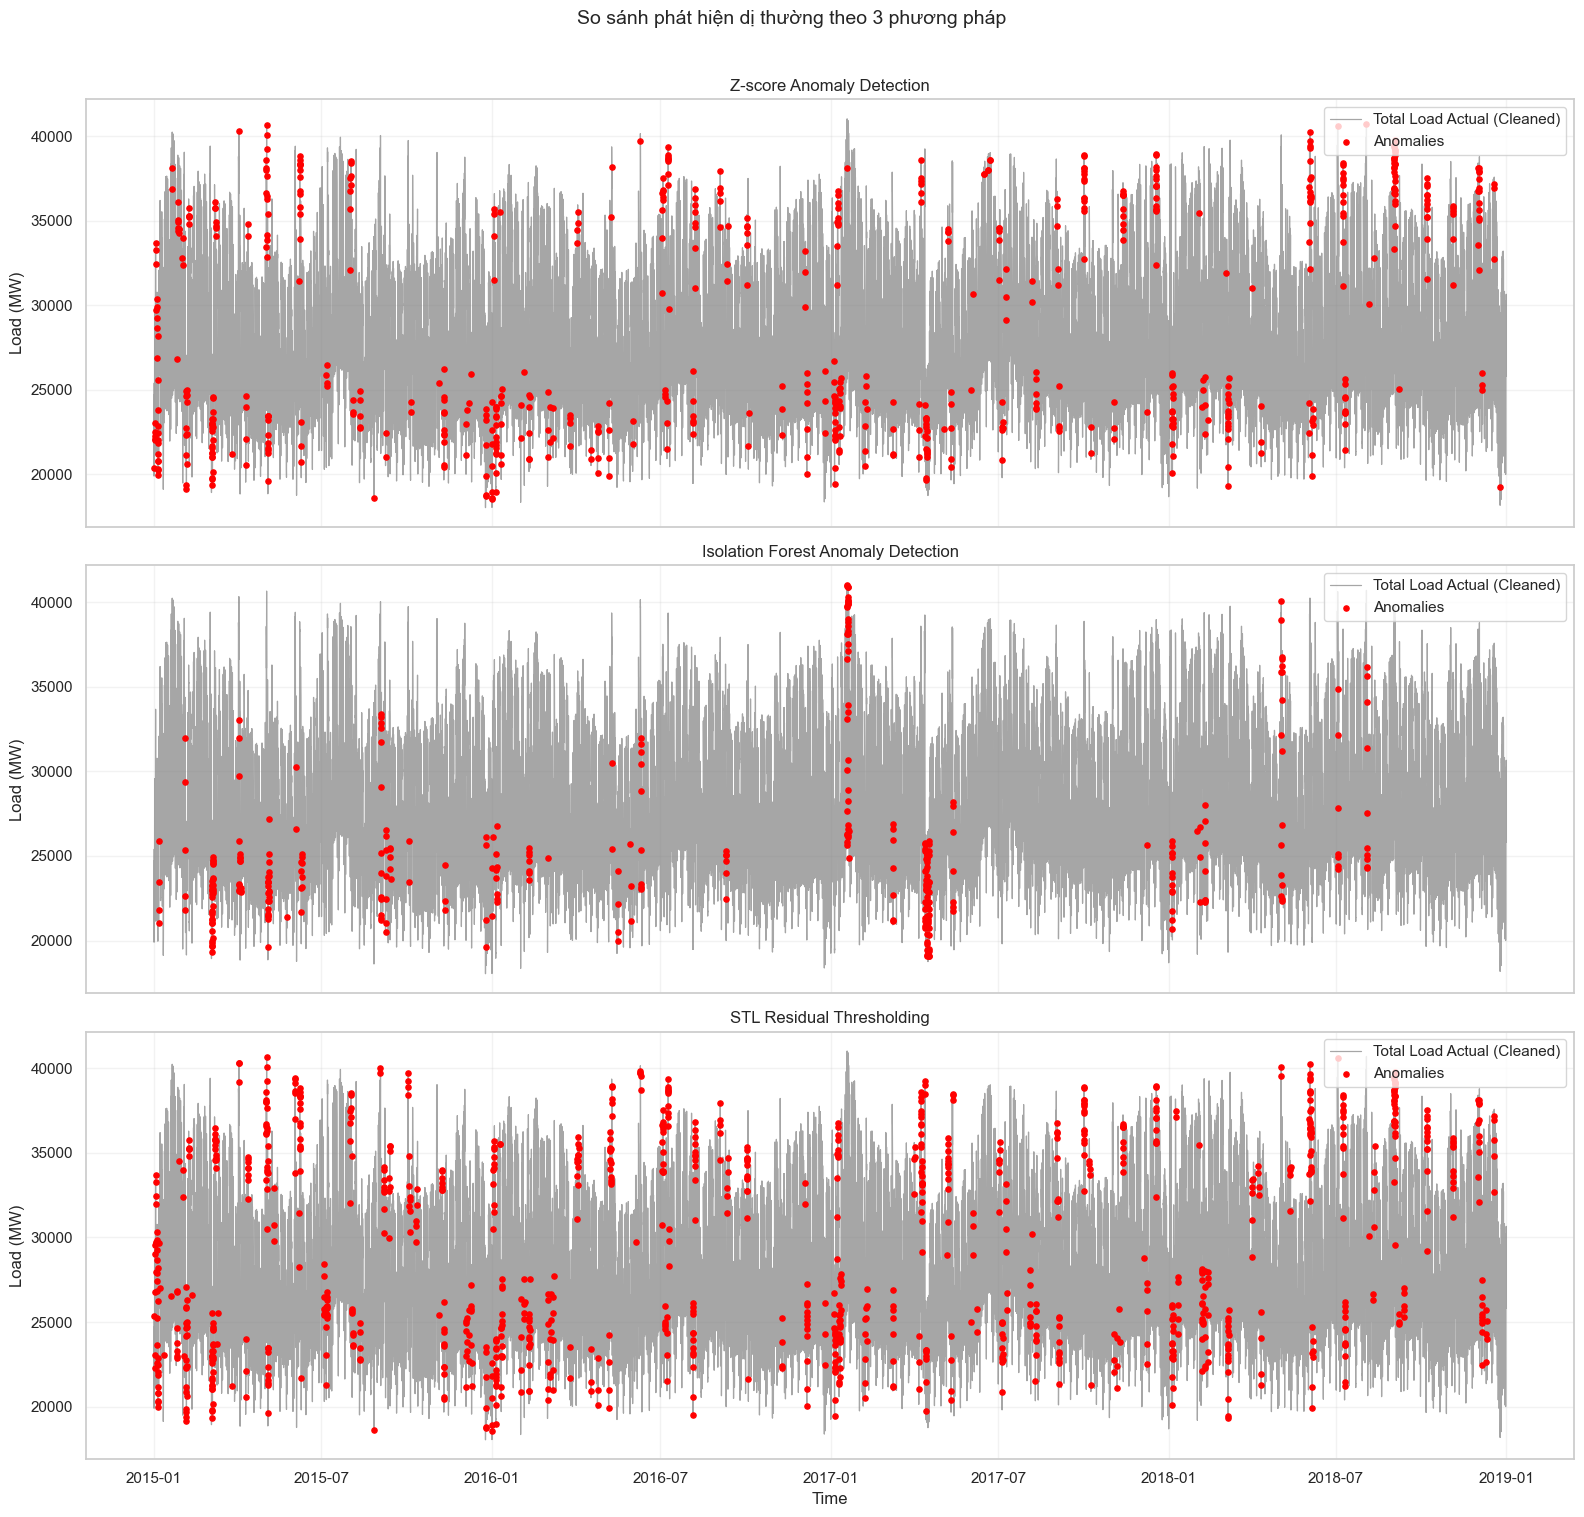

In [4]:
methods = [
    ('Z_Score_Anomaly', 'Z-score Anomaly Detection'),
    ('IsoForest_Anomaly', 'Isolation Forest Anomaly Detection'),
    ('STL_Resid_Anomaly', 'STL Residual Thresholding')
]

fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=True)

for ax, (col, title) in zip(axes, methods):
    # Đường tiêu thụ năng lượng
    ax.plot(ts_clean.index, ts_clean, color='gray', alpha=0.7, linewidth=0.9, label='Total Load Actual (Cleaned)')

    # Điểm dị thường (màu đỏ)
    anomaly_points = ts_clean[anomalies[col] == 1]
    ax.scatter(anomaly_points.index, anomaly_points, color='red', s=14, zorder=5, label='Anomalies')

    ax.set_title(title)
    ax.set_ylabel('Load (MW)')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.25)

axes[-1].set_xlabel('Time')
plt.suptitle('So sánh phát hiện dị thường theo 3 phương pháp', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Phân tích và thảo luận kết quả phát hiện dị thường 

Dựa trên kết quả định lượng và biểu đồ trực quan, ta có thể đánh giá về hiệu năng của 3 phương pháp :

**1. So sánh định lượng giữa các phương pháp:**
* **Isolation Forest trên cửa sổ trượt (350 điểm):** Phát hiện ít dị thường nhất do cấu hình `contamination=0.01` khắt khe và thao tác trên dữ liệu đã được smoothen bởi cửa sổ 24h. Thuật toán có xu hướng bỏ qua các dị thường cục bộ và chỉ bắt các bất thường có tính ngữ cảnh rộng hơn (contextual anomalies)
* **Z-score trên chuỗi Deseasonalized (662 điểm):** Đạt mức trung bình. Tuy đã loại bỏ mùa vụ, nhưng chuỗi Deseasonalized vẫn chứa thành phần xu hướng (trend). Sự biến động tự nhiên của trend đôi khi làm sai lệch mean cục bộ, khiến Z-score bỏ sót nhiều bất thường thực sự hoặc đánh dấu nhầm.
* **STL Residual Thresholding (1055 điểm):** Thể hiện độ nhạy bén cao nhất. Nhờ tách biệt Trend và Seasonality của LOESS, phần dư (residuals) chỉ còn chứa các diểm dị thường ngẫu nhiên. Áp dụng ngưỡng $3\sigma$ trên phần dư này giúp khoanh vùng các thời điểm hệ thống chệch khỏi trạng thái bình thường một cách khách quan.

**2. Phân tích trực quan và thảo luận nguyên nhân thực tế:**
Quan sát biểu đồ `Phát hiện dị thường bằng STL Residual Thresholding`, ta thấy các đốm đỏ (anomalies) phân bố ở **cả hai cực của biên độ dao động**, đại diện cho hai hiện tượng vĩ mô hoàn toàn trái ngược nhau:

* **Trường hợp 1: Dị thường ở các spike cắm thẳng xuống (~18.000 MW hoặc thấp hơn)**
  * *Hiện tượng:* Phụ tải sụt giảm đột ngột và sâu hơn mức đáy bình thường.
  * *Nguyên nhân thực tiễn:* Chủ yếu do **Hiệu ứng ngày lễ (Holiday effects)**. Vào các kỳ nghỉ lễ lớn (Tết Dương lịch, Giáng sinh), khối sản xuất công nghiệp và dịch vụ đồng loạt đóng cửa, khiến phần phụ tải nền bốc hơi đột ngột.

* **Trường hợp 2: Dị thường ở các spike dựng đứng lên (~40.000 MW)**
  * *Hiện tượng:* Phụ tải tăng vọt, phá vỡ cấu trúc đỉnh của ngày/tuần thông thường.
  * *Nguyên nhân thực tiễn:* Đây có thể là do **thay đổi thời tiết cực đoan**. Các đợt sóng nhiệt vào mùa hè khiến người dân dùng điều hòa nhiều, hoặc các đợt rét đậm vào mùa đông đẩy nhu cầu sưởi ấm lên cao. 

**3. Kết luận:**
Phương pháp **Dựa trên tái tạo (STL Residual Thresholding)** là công cụ tốt nhất để bóc tách các bất thường mang tính ngoại sinh (thời tiết, ngày lễ) khỏi chu kỳ nội sinh (sinh hoạt ngày/đêm) của chuỗi thời gian. Kết quả này không chỉ giúp làm sạch dữ liệu mà còn mở ra hướng feature engineering như thêm dữ liệu nhiệt độ cực đoan vào mô hình dự báo để nâng cao độ chính xác.

### b) Xây dựng ma trận đặc trưng & trích xuất đặc trưng thời gian 
Trích xuất đặc trưng chu kỳ (sin/cos), ngày lễ, đặc trưng thống kê trượt và các biến trễ (lag features)

In [5]:
feature_df = pd.DataFrame(index=ts_clean.index)
feature_df['load'] = ts_clean

# 1. Lag features: Cắt ở lag 1 và 2 dựa vào PACF
# Dựa vào phân tích PACF ở notebook 01, ta chọn các lag quan trọng là 1, 2, 3 và 24 để tạo thành các biến trễ
important_lags = [1, 2, 3, 24]
for lag in important_lags: 
    feature_df[f'lag_{lag}'] = ts_clean.shift(lag)


# 2. Rolling statistics đa khung thời gian: 6h, 24h, 168h
for w in [6, 24, 168]:
    feature_df[f'roll_mean_{w}'] = ts_clean.rolling(window=w).mean()
    feature_df[f'roll_std_{w}'] = ts_clean.rolling(window=w).std()
    feature_df[f'roll_min_{w}'] = ts_clean.rolling(window=w).min()
    feature_df[f'roll_max_{w}'] = ts_clean.rolling(window=w).max()

# 3. Cyclic Encoding cho giờ, thứ trong tuần, tháng
hours = feature_df.index.hour
dayofweek = feature_df.index.dayofweek
months = feature_df.index.month

feature_df['hour_sin'] = np.sin(2 * np.pi * hours / 24)
feature_df['hour_cos'] = np.cos(2 * np.pi * hours / 24)
feature_df['dayofweek_sin'] = np.sin(2 * np.pi * dayofweek / 7)
feature_df['dayofweek_cos'] = np.cos(2 * np.pi * dayofweek / 7)
feature_df['month_sin'] = np.sin(2 * np.pi * months / 12)
feature_df['month_cos'] = np.cos(2 * np.pi * months / 12)

# 4. Ngày lễ (dùng quốc gia tương ứng với dữ liệu năng lượng: Tây Ban Nha)
es_holidays = holidays.Spain(years=feature_df.index.year.unique())
feature_df['is_holiday'] = feature_df.index.normalize().isin(es_holidays).astype(int)

# 5. Chuỗi đã phân rã
feature_df['stl_trend'] = stl_trend
feature_df['stl_seasonal'] = stl_seasonal

# 6. Sai phân bậc 1 (từ notebook 02)
feature_df['diff_1'] = ts_diff

# Tạo target dự báo t+1
feature_df['target_t_plus_1'] = ts_clean.shift(-1)

feature_df = feature_df.dropna()
display(feature_df.head())

,load,lag_1,lag_2,lag_3,lag_24,roll_mean_6,roll_std_6,roll_min_6,roll_max_6,roll_mean_24,...,hour_cos,dayofweek_sin,dayofweek_cos,month_sin,month_cos,is_holiday,stl_trend,stl_seasonal,diff_1,target_t_plus_1
time,,,,,,,,,,,,,,,,,,,,,
2015-01-08 04:00:00+00:00,22361.0,22587.0,23046.0,23889.0,26021.000000,23969.500000,1713.826450,22361.0,26788.0,31256.096030,...,5.000000e-01,0.433884,-0.900969,0.5,0.866025,0,27692.798949,-6272.971444,-5.790528,22551.0
2015-01-08 05:00:00+00:00,22551.0,22361.0,22587.0,23046.0,26936.304732,23263.333333,1073.515471,22361.0,25146.0,31073.375000,...,2.588190e-01,0.433884,-0.900969,0.5,0.866025,0,27717.388272,-5610.308874,4.869567,22543.0
2015-01-08 06:00:00+00:00,22543.0,22551.0,22361.0,22587.0,28625.000000,22829.500000,566.984215,22361.0,23889.0,30819.958333,...,6.123234e-17,0.433884,-0.900969,0.5,0.866025,0,27741.934803,913.324095,-0.204731,24042.0
2015-01-08 07:00:00+00:00,24042.0,22543.0,22551.0,22361.0,31015.000000,22855.000000,624.671113,22361.0,24042.0,30529.416667,...,-2.588190e-01,0.433884,-0.900969,0.5,0.866025,0,27766.437647,1159.404544,37.911113,25932.0
2015-01-08 08:00:00+00:00,25932.0,24042.0,22543.0,22551.0,33276.000000,23336.000000,1413.814132,22361.0,25932.0,30223.416667,...,-5.000000e-01,0.433884,-0.900969,0.5,0.866025,0,27790.895552,-601.839738,46.589495,27664.0


### f) Lựa chọn độ trễ (Lag) và chuẩn bị dữ liệu dự báo $t+1$

Dựa trên biểu đồ PACF, nhóm chọn các độ trễ có ý nghĩa thống kê: **1, 2, 3 và 24**.
- **Lag 1, 2:** Tương quan dương mạnh với thời điểm hiện tại.
- **Lag 3:** Tương quan nghịch đáng kể, phản ánh hiệu ứng điều chỉnh ngắn hạn.
- **Lag 24:** Đại diện cho chu kỳ theo ngày (24 giờ).

Thay vì tạo toàn bộ 24 lag (dễ tăng nhiễu và số chiều), chỉ giữ các lag quan trọng để mô hình học hiệu quả hơn.

Trong bước này, dữ liệu được đưa về dạng supervised cho bài toán dự báo **$t+1$**:
- Tạo các cột lag từ `load`.
- Loại bỏ các dòng NaN phát sinh do `shift`/`rolling`.
- Tách `X_processed` (features) và `y_processed` (target).

In [6]:
# Chuẩn bị dữ liệu supervised cho bài toán dự báo t+1
target_col = 'target_t_plus_1'
significant_lags = [1, 2, 3, 24]

model_df = feature_df.copy()

# Tạo các đặc trưng trễ từ chuỗi load
for lag in significant_lags:
    model_df[f'lag_{lag}'] = model_df['load'].shift(lag)

# Loại bỏ NaN do shift/rolling/target shift
model_df = model_df.dropna().copy()

# Tách X (features) và y (target)
exclude_cols = {target_col, 'time', 'date'}
feature_cols = [col for col in model_df.columns if col not in exclude_cols]
X_processed = model_df[feature_cols]
y_processed = model_df[target_col]

print('=== XÂY DỰNG MA TRẬN ĐẶC TRƯNG ===')
print(f'Số mẫu: {len(model_df)}')
print(f'Số đặc trưng: {len(feature_cols)}')

=== XÂY DỰNG MA TRẬN ĐẶC TRƯNG ===
Số mẫu: 34836
Số đặc trưng: 27


### c) Huấn luyện mô hình dự báo & đánh giá 
Huấn luyện mô hình để dự báo $t+1$ và đánh giá chất lượng của Pipeline tiền xử lý thông qua MAE, RMSE.

- Mô hình: **Random Forest Regressor**
- Train/Test Split: Sử dụng năm cuối cùng làm tập Test (~8760 giờ), phần còn lại (3 năm đầu) làm tập Train

**1. Cơ sở lý thuyết:**
Random Forest Regressor là mô hình tổ hợp nhiều cây quyết định và lấy trung bình dự báo để giảm phương sai, giúp ổn định kết quả trên dữ liệu có quan hệ phi tuyến. Chất lượng dự báo được đo bằng MAE và RMSE.

**2. Công thức toán học:**
- **Dự báo của Random Forest:**
$$
\hat{y}_t = \frac{1}{B}\sum_{b=1}^{B} T_b(X_t)
$$
với $T_b$ là cây thứ $b$, $B$ là số cây.

- **MAE:**
$$
\mathrm{MAE}=\frac{1}{n}\sum_{t=1}^{n}|y_t-\hat{y}_t|
$$

- **RMSE:**
$$
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{t=1}^{n}(y_t-\hat{y}_t)^2}
$$

**3. Ứng dụng trong bài toán:**
MAE phản ánh sai số tuyệt đối trung bình dễ diễn giải theo đơn vị MW, còn RMSE nhấn mạnh các sai số lớn, rất hữu ích để đánh giá độ nhạy của mô hình trước các biến động phụ tải bất thường.

In [7]:
# Lấy năm cuối cùng làm tập Test
test_size = 24 * 365  
train_df = feature_df.iloc[:-test_size]
test_df = feature_df.iloc[-test_size:]

X_train = train_df.drop(columns=['target_t_plus_1'])
y_train = train_df['target_t_plus_1']
X_test = test_df.drop(columns=['target_t_plus_1'])
y_test = test_df['target_t_plus_1']

print("Đang huấn luyện Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Kết quả đánh giá trên tập Test ---")
print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")

Đang huấn luyện Random Forest...

--- Kết quả đánh giá trên tập Test ---
MAE:  304.15 MW
RMSE: 505.03 MW


#### Nhận xét kết quả dự báo 
Kết quả dự báo trên tập Test (năm 2018) bằng mô hình `Random Forest Regressor` đã cung cấp bằng chứng định lượng vững chắc cho hiệu quả của tổng thể pipeline tiền xử lý:

**1. Đánh giá mức độ chính xác trong ngữ cảnh thực tế:**
* Sai số tuyệt đối trung bình (MAE) đạt **304.15 MW**. So với mức tiêu thụ phụ tải trung bình của toàn hệ thống (khoảng 28.700 MW), sai số dự báo chỉ chiếm xấp xỉ **1%**. Đây là một độ chính xác rất cao.
* Sự thành công này phần lớn đến từ bước **Feature Engineering**. Việc áp dụng STL decomposition để trích xuất trước thành phần Mùa vụ (`stl_seasonal`), kết hợp với các biến trễ (lag features) đã giúp Random Forest dễ dàng nắm bắt được quy luật nội tại của chuỗi mà không bị nhiễu.

**2. Đánh giá cấu trúc sai số qua độ lệch (RMSE vs MAE):**
* RMSE đạt **505.03 MW**, cao hơn MAE khoảng 200 MW. Sự chênh lệch này phản ánh đúng đặc thù của dữ liệu: Mặc dù dự báo rất tốt ở các khung giờ bình thường, mô hình thỉnh thoảng vẫn gặp phải các sai số lớn cục bộ.
* Liên hệ với phân tích **Phát hiện dị thường**, các sai số lớn này chính là những cú sốc ngoại sinh (thời tiết cực đoạn hoặc ngày lễ) diễn ra đột ngột mà dữ liệu tự thân của hệ thống không thể dự báo trước 100%.

**Kết luận chung:** Pipeline tiền xử lý được thiết kế trong đồ án không chỉ làm sạch dữ liệu thô mà còn tạo ra một không gian đặc trưng chất lượng cao, giúp một thuật toán học máy cơ bản như Random Forest cũng có thể đạt được hiệu suất dự báo xuất sắc.

#### Trực quan hóa Feature Importance

Top 10 Đặc trưng quan trọng nhất:
1. load - Importance: 0.8958
2. diff_1 - Importance: 0.0497
3. hour_cos - Importance: 0.0305
4. hour_sin - Importance: 0.0033
5. roll_min_6 - Importance: 0.0027
6. roll_max_6 - Importance: 0.0026
7. roll_min_24 - Importance: 0.0024
8. roll_std_6 - Importance: 0.0012
9. roll_mean_6 - Importance: 0.0011
10. stl_trend - Importance: 0.0011




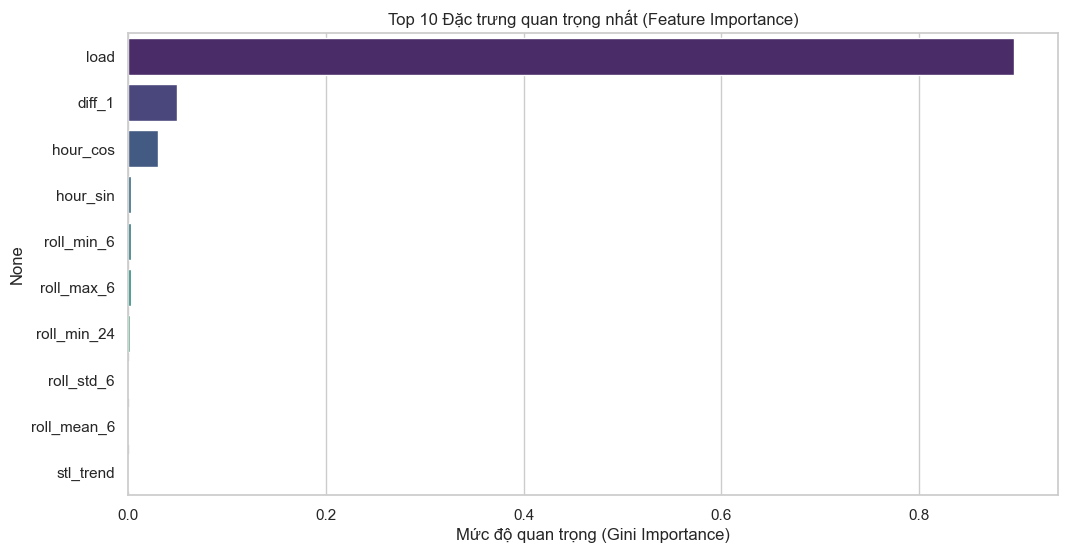

In [8]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

# table
print("Top 10 Đặc trưng quan trọng nhất:")
for i in range(10):
    print(f"{i+1}. {features[indices][i]} - Importance: {importances[indices][i]:.4f}")
print("\n")

# plot
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices][:10], y=features[indices][:10], palette='viridis')
plt.title('Top 10 Đặc trưng quan trọng nhất (Feature Importance)')
plt.xlabel('Mức độ quan trọng (Gini Importance)')
plt.show()

#### Nhận xét Feature Importance

**1. Tính tự tương quan (Autoregressive) chi phối mạnh nhất:**
- Đặc trưng `load` (89.51%) và `diff_1` (5.04%) chiếm gần 95% mức độ đóng góp. Điều này chứng tỏ trạng thái tiêu thụ năng lượng hiện tại phụ thuộc chủ yếu vào trạng thái và đà thay đổi của bước thời gian liền kề trước đó.

**2. Ảnh hưởng của chu kỳ:**
- `hour_cos` (3.07%) và `hour_sin` (0.29%) lọt top đầu cho thấy mô hình đã nắm bắt rất tốt chu kỳ tiêu thụ lặp lại mỗi 24 giờ (đỉnh điểm và thấp điểm trong ngày).

**3. Vai trò tinh chỉnh của Rolling & Phân rã:**
- Các đặc trưng cửa sổ trượt (`roll_min/max/mean/std_6`, `roll_min_24`) và phân rã (`stl_trend`) có tỷ trọng nhỏ (< 1%) nhưng đóng vai trò như các bộ lọc nhiễu, giúp mô hình tinh chỉnh dự báo dựa trên các cú sốc cục bộ và xu hướng vĩ mô.

### d) Phân tích Nhân quả Granger (Granger Causality)

Kiểm tra mối quan hệ nhân quả (Granger-cause) giữa Giá điện thực tế và Nhu cầu tiêu thụ điện.

Thay vì dùng lại dữ liệu thô và áp dụng hàm phân sai thủ công, nhóm quyết định kế thừa trực tiếp chuỗi đã đạt tính dừng `ts_diff` (hoặc `stl_resid`) từ bước phân rã và kiểm định tính dừng trước đó. Đồng thời, nhóm cũng lấy sai phân bậc 1 cho các biến ngoại sinh (Price, Solar, Wind, Gas) để tạo thành một **DataFrame đa biến dừng**. Việc chuẩn hóa tính dừng đồng loạt này giúp loại bỏ *tương quan giả* do xu hướng hoặc tính mùa vụ gây ra, từ đó đảm bảo kiểm định Granger phản ánh quan hệ dẫn dắt theo thời gian một cách đáng tin cậy hơn.


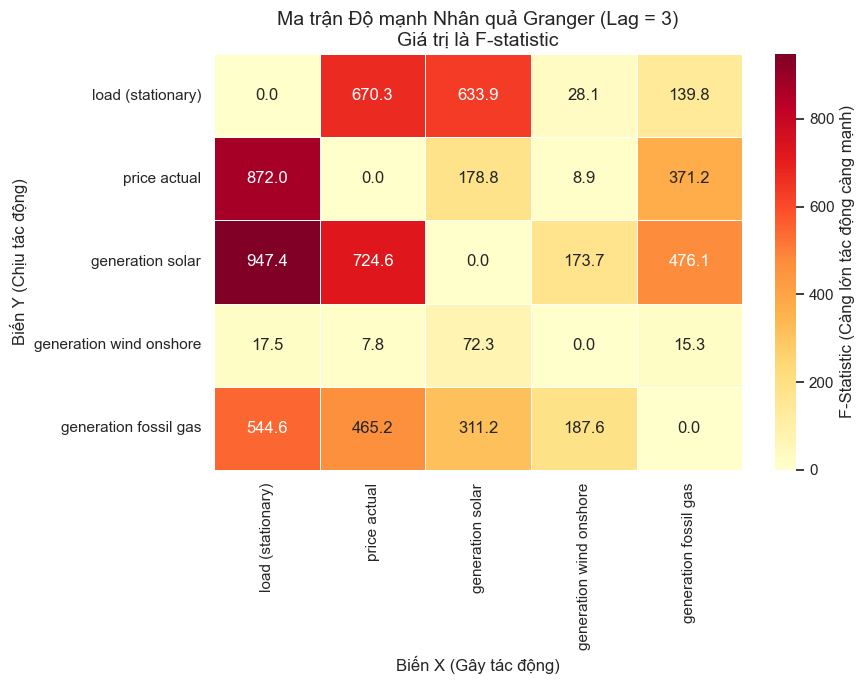

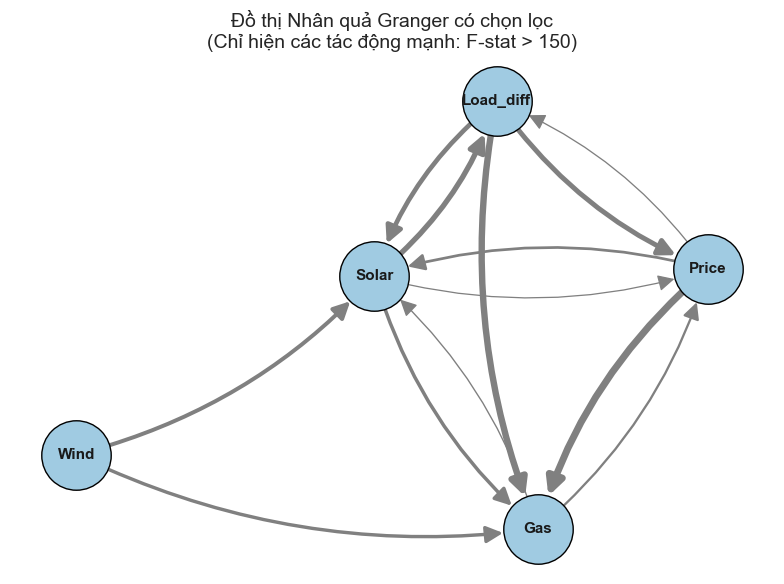

In [9]:
# 1. Load dữ liệu
df_raw = pd.read_csv('../data/raw/P4_energy_dataset.csv', parse_dates=['time']).set_index('time')
df_raw.index = pd.to_datetime(df_raw.index, utc=True)

# Dữ liệu đã xử lý từ notebook trước (đảm bảo có ts_diff)
df_processed = df_proc.copy()

# 1. Chuẩn bị dữ liệu đa biến dừng (stationary)
# Biến Y (Target): chuỗi đã dừng (sai phân)
target_series = df_processed['ts_diff'].rename('load (stationary)')

# Các biến X (Predictors): lấy từ dữ liệu gốc
predictor_cols = [
    'price actual',
    'generation solar',
    'generation wind onshore',
    'generation fossil gas'
 ]

# Nội suy để điền khuyết
df_predictors = df_raw[predictor_cols].interpolate(method='linear')

# Lấy sai phân bậc 1 cho predictors để đảm bảo tính dừng
df_predictors_stationary = df_predictors.diff()

# Gộp thành DataFrame đa biến để chạy kiểm định Granger
df_granger = pd.concat([target_series, df_predictors_stationary], axis=1).dropna()


# 2. Chạy vòng lặp kiểm định trên df_granger
maxlag = 3
variables = df_granger.columns.tolist()

f_matrix = pd.DataFrame(
    np.zeros((len(variables), len(variables))),
    columns=variables,
    index=variables
)

for target in variables:
    for predictor in variables:
        if target == predictor:
            f_matrix.loc[target, predictor] = 0.0
        else:
            test_result = grangercausalitytests(
                df_granger[[target, predictor]],
                maxlag=[maxlag],
                verbose=False
            )
            f_stat = test_result[maxlag][0]['ssr_ftest'][0]
            f_matrix.loc[target, predictor] = f_stat


# --- TRỰC QUAN HÓA 1: HEATMAP ĐỘ MẠNH NHÂN QUẢ ---
plt.figure(figsize=(9, 7))
sns.heatmap(
    f_matrix,
    annot=True,
    cmap='YlOrRd',
    fmt='.1f',
    linewidths=.5,
    cbar_kws={'label': 'F-Statistic (Càng lớn tác động càng mạnh)'}
)
plt.title(f'Ma trận Độ mạnh Nhân quả Granger (Lag = {maxlag})\nGiá trị là F-statistic', fontsize=14)
plt.ylabel('Biến Y (Chịu tác động)')
plt.xlabel('Biến X (Gây tác động)')
plt.tight_layout()
plt.show()

# to csv this heatmap
f_matrix.to_csv('../granger_f_stat_matrix.csv')

# --- TRỰC QUAN HÓA 2: ĐỒ THỊ CÓ HƯỚNG ---
name_map = {
    'load (stationary)': 'Load_diff',
    'price actual': 'Price',
    'generation solar': 'Solar',
    'generation wind onshore': 'Wind',
    'generation fossil gas': 'Gas'
}

G = nx.DiGraph()
G.add_nodes_from(name_map.values())

# Lọc: Chỉ lấy những kết nối có F-statistic lớn hơn một ngưỡng
f_threshold = 150
edges = []
edge_weights = []

for target in variables:
    for predictor in variables:
        f_val = f_matrix.loc[target, predictor]
        if target != predictor and f_val > f_threshold:
            edges.append((name_map[predictor], name_map[target]))
            edge_weights.append(f_val)

G.add_edges_from(edges)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)

# Vẽ Nodes
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='#A0CBE2', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')

# Vẽ Edges với độ dày tỷ lệ thuận với độ mạnh F-statistic
if edge_weights:
    weights_normalized = [w / max(edge_weights) * 5 for w in edge_weights]
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=G.edges(),
        width=weights_normalized,
        arrowsize=25,
        arrowstyle='-|>',
        node_size=2500,
        connectionstyle='arc3,rad=0.15',
        edge_color='gray'
    )

plt.title(f'Đồ thị Nhân quả Granger có chọn lọc\n(Chỉ hiện các tác động mạnh: F-stat > {f_threshold})', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

#### Nhận xét Nhân quả Granger

Dựa trên ma trận F-statistic (Lag = 3) từ các chuỗi dữ liệu đã đạt tính dừng, ta có thể rút ra các quy luật tác động chính trên thị trường năng lượng:

**1. Tải tiêu thụ (load) là tác nhân dẫn dắt mạnh nhất:**
- **`load` $\rightarrow$ `generation solar` (F = 947.4) và `load` $\rightarrow$ `price actual` (F = 872.0):** Sự thay đổi của tải tiêu thụ có sức ảnh hưởng cực kỳ lớn lên giá điện (theo quy luật cung cầu). Tác động lên điện mặt trời có thể do sự tương quan ẩn về thời điểm cao điểm trong ngày.
- **`load` $\rightarrow$ `generation fossil gas` (F = 544.6):** Điện khí phản ứng tức thời với biến động của tải tiêu thụ, minh chứng cho vai trò là nguồn chính và linh hoạt của hệ thống.

**2. Các yếu tố chi phối ngược lại tải tiêu thụ:**
- **`price actual` $\rightarrow$ `load` (F = 670.3):** Giá cả tác động ngược lại nhu cầu tiêu thụ, phản ánh sự điều chỉnh hành vi sử dụng điện dựa trên giá của thị trường.
- **`generation solar` $\rightarrow$ `load` (F = 633.9):** Sản lượng điện mặt trời thay đổi (ví dụ: có những mùa ít nắng, trời tối) gây ảnh hưởng mạnh lên tải thực tế mà hệ thống điện truyền thống phải gánh.

**3. Điện gió (Wind onshore) có tính độc lập rất cao:**
- Nhìn vào hàng `generation wind onshore` (khi đóng vai trò biến bị tác động), các giá trị F-statistic đều rất thấp (chỉ dao động từ 7.8 đến 72.3). Điều này hoàn toàn hợp lý với thực tế tự nhiên: gió thổi độc lập với nhu cầu tiêu thụ điện, giá cả hay các nguồn phát khác.

>(Lưu ý: Các phân tích trên dựa trên cường độ F-statistic. Để khẳng định chắc chắn về mặt thống kê, các cặp quan hệ này cần đối chiếu thêm điều kiện P-value < 0.05).*